# SGKAN — TF1 Uzerinde Adim Adim

Bu notebook, SWIM + Yerel Kernel-Ozellik (GP-esinlenmis, ama edge seviyesinde
sikistirma yapmayan) + Ridge yaklasimini, coklu-katmanli KAN yapisiyla TF1
uzerinde calistirir.

**Mimari ozeti:**
1. Her noron icin SWIM ile bir cift secilir (veri-gudumlu yerlesim)
2. Her boyut (p) icin, o ciftin projeksiyonuna gore yerel veri toplanir
3. Yerel veriden inducing noktalar secilir, medyan sezgisiyle lengthscale
   hesaplanir -- TAMAMEN y-BAGIMSIZ, sadece x'ten
4. Tum boyutlarin kernel ozellikleri yan yana konup TEK bir Ridge ile y'ye
   fit edilir (y'ye SADECE BIR KEZ bakiliyor -- circularity yok)
5. Ridge'in agirliklari boyutlara gore dilimlenir -> GERCEK, bagimsiz
   univariate kenar fonksiyonlari (phi_{q,p}(x_p)) elde edilir
6. Katmanlar zincirlenir (bir katmanin ciktisi, sonrakinin girdisi olur)

Hicbir adimda gradient descent / iteratif optimizasyon yok -- hepsi formul
veya tek seferlik kapali-form matris cebiri.

## Adim 0 — Kutuphaneler ve TF1 verisini yukleme

`tf1_x_train`, `tf1_y_train` (ve varsa `tf1_x_test`, `tf1_y_test`) degiskenlerini
kendi TF1 yukleme kodunuzla doldurun. Asagidaki hucre placeholder -- zaten
notebook'unuzda TF1'i nasil yuklediyseniz o kodu buraya koyun.

In [1]:
import numpy as np
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

# --- TF1 verisini buraya yukleyin (kendi yukleme koduzu kullanin) ---
# Ornek: tf1_x_train, tf1_y_train = load_tf1(...)
# Asagida, eger daha once tanimlamadiysaniz, KUCUK bir sentetik yer-tutucu var --
# kendi TF1'inizi yukledikten sonra bu hucreyi calistirmaniza gerek YOK.

DATA_DIR = "data"
tf1_trn = np.loadtxt(f"{DATA_DIR}/TF3_trn.csv", delimiter=",")
tf1_tst = np.loadtxt(f"{DATA_DIR}/TF3_tst.csv", delimiter=",")

tf1_x_train, tf1_y_train = tf1_trn[:, :-1], tf1_trn[:, -1]
tf1_x_test,  tf1_y_test  = tf1_tst[:, :-1], tf1_tst[:, -1]

print(tf1_x_train.shape, tf1_x_test.shape)

try:
    print("tf1_x_train / tf1_y_train zaten tanimli, bu haliyle kullaniliyor.")
    print("tf1_x_train shape:", tf1_x_train.shape)
    print("tf1_y_train shape:", tf1_y_train.shape)
except NameError:
    print("UYARI: tf1_x_train/tf1_y_train bulunamadi -- sentetik yer-tutucu olusturuluyor.")
    print("Kendi TF1 verinizi yukledikten sonra bu hucreyi TEKRAR calistirin.")
    rng = np.random.default_rng(0)
    M = 5000
    tf1_x_train = rng.uniform(0, 1, size=(M, 2))
    tf1_y_train = (0.3 * tf1_x_train[:, 0] - 0.2 * tf1_x_train[:, 1]
                   + 0.8 * tf1_x_train[:, 0] * tf1_x_train[:, 1] + 0.1)


(5000, 2) (10000, 2)
tf1_x_train / tf1_y_train zaten tanimli, bu haliyle kullaniliyor.
tf1_x_train shape: (5000, 2)
tf1_y_train shape: (5000,)


## Adim 1 — SWIM ile cift secimi

Her noron (q) icin, tum boyutlari kullanarak rastgele aday ciftler
olusturuyoruz, skor (`|dy|/||dx||`) ile agirliklandirip en yuksek skorlulari
seciyoruz -- SWIM'in temel mantigi.

In [2]:
def select_pairs_gen(X, y, layer_width, random_seed=None, n_candidates=2000):
    M = X.shape[0]
    rng = np.random.default_rng(random_seed)
    idx_a = rng.integers(0, M, size=n_candidates)
    idx_b = rng.integers(0, M, size=n_candidates)
    x_a_cand, x_b_cand = X[idx_a], X[idx_b]
    y_a_cand, y_b_cand = y[idx_a], y[idx_b]
    dist = np.maximum(np.linalg.norm(x_a_cand - x_b_cand, axis=1), 1e-8)
    score = np.abs(y_a_cand - y_b_cand) / dist
    probs = score / score.sum()
    selected_idx = rng.choice(n_candidates, size=layer_width, replace=False, p=probs)
    return x_a_cand[selected_idx], x_b_cand[selected_idx]

# Hizli test
x_a_test, x_b_test = select_pairs_gen(tf1_x_train, tf1_y_train, layer_width=3, random_seed=0)
print("x_a_test shape:", x_a_test.shape)   # (3, D)
print("x_b_test shape:", x_b_test.shape)


x_a_test shape: (3, 2)
x_b_test shape: (3, 2)


## Adim 2 — Yerel veri toplama

Secilen cift, her boyutta bir `[lo, hi]` araligina projekte ediliyor. O
araliga dusen egitim noktalari toplaniyor. Cok azsa (`knn_fallback`) en
yakin komsulara, cok fazlaysa (`interval_capped`) merkeze en yakin sabit
sayida noktaya dusuluyor.

In [3]:
def collect_local_gen(X, y, p, lo, hi, min_points=5, max_points=1000, k_fallback=10):
    x_p = X[:, p]
    mask = (x_p >= lo) & (x_p <= hi)
    n_inside = int(mask.sum())
    midpoint = (lo + hi) / 2
    if n_inside >= min_points:
        x_inside, y_inside = x_p[mask], y[mask]
        if n_inside <= max_points:
            return x_inside, y_inside, "interval"
        order = np.argsort(np.abs(x_inside - midpoint))
        cap_idx = order[:max_points]
        return x_inside[cap_idx], y_inside[cap_idx], "interval_capped"
    order = np.argsort(np.abs(x_p - midpoint))
    knn_idx = order[:k_fallback]
    return x_p[knn_idx], y[knn_idx], "knn_fallback"

# Hizli test -- q=0, p=0 icin
q, p = 0, 0
lo = min(x_a_test[q, p], x_b_test[q, p])
hi = max(x_a_test[q, p], x_b_test[q, p])
local_x_p, local_y, method = collect_local_gen(tf1_x_train, tf1_y_train, p, lo, hi)
print(f"method={method}, local_x_p shape={local_x_p.shape}, local_y shape={local_y.shape}")


method=interval_capped, local_x_p shape=(1000,), local_y shape=(1000,)


## Adim 3 — Inducing noktalar + medyan sezgisi (y-BAGIMSIZ kernel ozellikleri)

Yerel veriden sabit sayida (`num_inducing`) nokta rastgele secilir (inducing
points). Lengthscale, yerel noktalarin kendi aralarindaki mesafelerin
medyaniyla (medyan sezgisi / median heuristic) belirlenir -- hicbir arama
yok, sadece formul.

**Onemli:** Bu fonksiyon `local_y`'yi hic kullanmiyor -- ciktisi (kernel ozellik
matrisi) tamamen `x`'ten turetiliyor, HKAN'daki basis-fonksiyon merkezlerinin
y-bagimsiz olmasi gibi.

**Kernel secenekleri:** `kernel_type` parametresiyle RBF (varsayilan), Matern
(5/2) veya Periodic (ExpSineSquared) arasinda secim yapabilirsiniz. Periyodik
kernel icin `period` sabit/elle verilir (y'den turetilmiyor -- y-bagimsizlik
ilkesini korumak icin).

In [4]:
def rbf_kernel(x1, x2, l_p):
    r2 = (x1[:, None] - x2[None, :]) ** 2
    return np.exp(-r2 / (2 * l_p ** 2))


def matern_kernel(x1, x2, l_p):
    """Matern nu=5/2 -- RBF'den daha az 'asiri pürüzsüz', keskin gecisleri
    daha iyi tolere edebilir."""
    r = np.abs(x1[:, None] - x2[None, :]) / l_p
    sqrt5_r = np.sqrt(5) * r
    return (1 + sqrt5_r + (5 / 3) * r ** 2) * np.exp(-sqrt5_r)


def periodic_kernel(x1, x2, l_p, period=1.0):
    """ExpSineSquared -- tekrarlayan/periyodik yapilar icin (orn. TF3).
    `period` SABIT/elle verilir -- y'den turetilmez, y-bagimsizlik ilkesi korunur."""
    r = np.abs(x1[:, None] - x2[None, :])
    return np.exp(-2 * np.sin(np.pi * r / period) ** 2 / (l_p ** 2))


def apply_kernel(x1, x2, l_p, kernel_type="rbf", period=1.0):
    if kernel_type == "rbf":
        return rbf_kernel(x1, x2, l_p)
    elif kernel_type == "matern":
        return matern_kernel(x1, x2, l_p)
    elif kernel_type == "periodic":
        return periodic_kernel(x1, x2, l_p, period=period)
    else:
        raise ValueError(f"Bilinmeyen kernel_type: {kernel_type}")


def build_edge_features(X, p, local_x_p, num_inducing=15, sigma_scale=1.0, seed=0,
                         kernel_type="rbf", period=1.0):
    n = local_x_p.shape[0]
    n_ind = min(num_inducing, n)

    rng = np.random.default_rng(seed)
    idx = rng.choice(n, size=n_ind, replace=False)
    z_p = np.sort(local_x_p[idx])

    diffs = np.abs(local_x_p[:, None] - local_x_p[None, :])
    mask_diag = ~np.eye(n, dtype=bool)
    l_p = sigma_scale * np.median(diffs[mask_diag]) if n > 1 else sigma_scale
    l_p = max(l_p, 1e-6)

    x_star = X[:, p]
    k_star = apply_kernel(x_star, z_p, l_p, kernel_type=kernel_type, period=period)  # (M, n_ind)

    return k_star, z_p, l_p

# Hizli test
k_feat_test, z_test, l_test = build_edge_features(tf1_x_train, p, local_x_p, num_inducing=15, seed=0)
print("k_feat_test shape:", k_feat_test.shape)   # (M, n_inducing)
print("z_test shape:", z_test.shape)
print("lengthscale:", round(l_test, 5))


k_feat_test shape: (5000, 15)
z_test shape: (15,)
lengthscale: 0.0553


## Adim 4 — Gercek univariate kenar fonksiyonu: phi_{q,p}(x_p)

Bu fonksiyon, sadece tek bir boyutun (`x_p_query`) fonksiyonu -- egitimde
gorulmus olsun olmasin herhangi bir `x_p` degeri icin degerlendirilebilir.
`w_p`, bir sonraki adimda (Adim 5) Ridge'den elde edilecek.

**Onemli:** Egitimde (Adim 3) hangi `kernel_type`/`period` kullanildiysa,
tahmin sirasinda da AYNISI kullanilmali -- yoksa egitilen `w_p` agirliklari
yanlis kernel ile eslesir.

In [5]:
def edge_function(x_p_query, z_p, l_p, w_p, kernel_type="rbf", period=1.0):
    k = apply_kernel(x_p_query, z_p, l_p, kernel_type=kernel_type, period=period)
    return k @ w_p


## Adim 5 — Bir katmanin tamami: ORTAK (joint) Ridge fit

Her noron (q) icin:
1. D boyutun her birinden `(M, n_inducing)` kernel ozelligi hesaplanir (y-bagimsiz)
2. Hepsi yan yana konup `(M, D*n_inducing)` birlesik matris olusturulur
3. **TEK bir Ridge**, bu birlesik matrisi `y`'ye fit eder (y'ye SADECE BURADA
   bakiliyor -- additive modellerin standart/dogru fit yontemi, "joint fit")
4. Ridge'in ogrendigi agirliklar, boyutlara gore dilimlenir -> her boyut icin
   ayri, gercek bir kenar fonksiyonu (w_p) elde edilir

Bu, standart KAN/HKAN'in additive yapisini koruyor, ama y'ye SADECE bir kez
bakildigi icin GP-tabanli iki-asamali versiyondaki circularity riskini tasimiyor.

**Kernel secimi:** `kernel_type` ("rbf", "matern", "periodic") ve periyodik
icin `period`, tum katmana tek seferde uygulanir (her (q,p) kenari ayni
kernel ailesini kullanir).

In [6]:
def fit_layer(X, y, layer_width, num_inducing=15, sigma_scale=1.0, alpha=1e-3, seed=0,
              kernel_type="periodic", period=1.0):
    D_in = X.shape[1]
    x_a, x_b = select_pairs_gen(X, y, layer_width, random_seed=seed)

    H = np.zeros((len(y), layer_width))
    neurons = []

    for q in range(layer_width):
        feature_blocks, z_list, l_list = [], [], []

        for p in range(D_in):
            lo = min(x_a[q, p], x_b[q, p])
            hi = max(x_a[q, p], x_b[q, p])
            local_x_p, _, _ = collect_local_gen(X, y, p, lo, hi)

            k_feat, z_p, l_p = build_edge_features(
                X, p, local_x_p, num_inducing=num_inducing,
                sigma_scale=sigma_scale, seed=seed + q,
                kernel_type=kernel_type, period=period)

            feature_blocks.append(k_feat)
            z_list.append(z_p)
            l_list.append(l_p)

        all_features = np.column_stack(feature_blocks)   # (M, D_in * n_ind)

        # --- TEK ORTAK Ridge fit -- y'ye SADECE burada bakiliyor ---
        model_q = Ridge(alpha=alpha, fit_intercept=True)
        model_q.fit(all_features, y)

        H[:, q] = model_q.predict(all_features)

        # --- agirliklari boyutlara gore dilimle -> GERCEK univariate kenarlar ---
        w_full = model_q.coef_
        sizes = [fb.shape[1] for fb in feature_blocks]
        w_per_dim = np.split(w_full, np.cumsum(sizes)[:-1])

        neurons.append({
            "z_list": z_list, "l_list": l_list,
            "w_per_dim": w_per_dim, "bias": model_q.intercept_,
            "kernel_type": kernel_type, "period": period,
        })

    return H, neurons


### Kernel secenekleri -- hizli deneme

Ayni kenari (q=0, p=0) uc farkli kernel ile kurup karsilastirin. `period`
simdilik sabit veriliyor (`period=1.0`, normalize [0,1] veri icin makul bir
varsayilan -- kendi verinize gore degistirebilirsiniz).

In [7]:
fixed_period = 1.0   # simdilik sabit -- veriden turetilmiyor (y-bagimsizlik icin)

for kt in ["rbf", "matern", "periodic"]:
    H1_kt, neurons1_kt = fit_layer(tf1_x_train, tf1_y_train, layer_width=50,
                                     num_inducing=15, alpha=1e-3, seed=0,
                                     kernel_type=kt, period=fixed_period)
    rmse_kt = np.sqrt(np.mean((H1_kt.mean(axis=1) - tf1_y_train) ** 2))  # kaba on-kontrol
    print(f"kernel_type={kt:10s} -- kaba on-kontrol RMSE (ortalama noron): {rmse_kt:.5f}")


kernel_type=rbf        -- kaba on-kontrol RMSE (ortalama noron): 0.12413
kernel_type=matern     -- kaba on-kontrol RMSE (ortalama noron): 0.13011
kernel_type=periodic   -- kaba on-kontrol RMSE (ortalama noron): 0.14381


## Adim 6 — Kurulu bir katmani yeni veriye uygulama (transform)

Egitimde ogrenilen kenar fonksiyonlarini (z_list, l_list, w_per_dim, bias)
kullanarak, herhangi bir yeni X icin katman ciktisini hesaplar. Bu, test
setinde degerlendirme yapmak icin gerekli.

In [8]:
def transform_layer(X_new, neurons):
    M_new = X_new.shape[0]
    layer_width = len(neurons)
    H_new = np.zeros((M_new, layer_width))

    for q, neuron in enumerate(neurons):
        D_in = len(neuron["z_list"])
        total = neuron["bias"] * np.ones(M_new)
        for p in range(D_in):
            edge_out = edge_function(X_new[:, p], neuron["z_list"][p],
                                       neuron["l_list"][p], neuron["w_per_dim"][p],
                                       kernel_type=neuron.get("kernel_type", "rbf"),
                                       period=neuron.get("period", 1.0))
            total += edge_out
        H_new[:, q] = total

    return H_new


## Adim 7 — Dogrulama: kenarlarin toplami, Ridge'in ciktisina esit mi?

Bu, kenarlara ayristirmanin matematiksel olarak dogru oldugunun kaniti --
fark, sayisal hassasiyet disinda sifir olmali.

In [9]:
def verify_edge_decomposition(X, y, neurons, H, tol=1e-8):
    H_recon = transform_layer(X, neurons)
    max_diff = np.max(np.abs(H_recon - H))
    print(f"Kenarlarin toplami ile Ridge ciktisi arasindaki max fark: {max_diff:.2e}")
    print("Tutarli mi (tol icinde)?", max_diff < tol)
    return max_diff


## Adim 8 — Katman 1'i egitim verisinde calistir

`layer_width_1` degerini deneyerek artirabilirsiniz (HKAN'daki gibi
yuzlerce nöron -- ensemble etkisi icin).

In [10]:
layer_width_1 = 200
num_inducing = 30
alpha = 1e-3

H1, neurons1 = fit_layer(tf1_x_train, tf1_y_train, layer_width_1,
                          num_inducing=num_inducing, alpha=alpha, seed=0)

print("H1 shape:", H1.shape)   # (M, layer_width_1)
verify_edge_decomposition(tf1_x_train, tf1_y_train, neurons1, H1)


H1 shape: (5000, 200)
Kenarlarin toplami ile Ridge ciktisi arasindaki max fark: 6.22e-15
Tutarli mi (tol icinde)? True


6.217248937900877e-15

## Adim 9 — Ornek bir kenari gorsellestir

Bir noronun bir kenarinin (phi_{q,p}(x_p)), gercekten sadece o boyuta
bagli, cizilebilir bir fonksiyon oldugunu goralim.

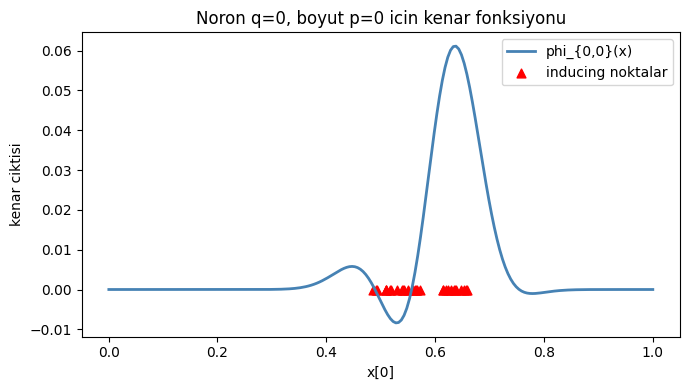

In [11]:
q_example, p_example = 0, 0
neuron = neurons1[q_example]
z_p = neuron["z_list"][p_example]
l_p = neuron["l_list"][p_example]
w_p = neuron["w_per_dim"][p_example]

x_dense = np.linspace(tf1_x_train[:, p_example].min(), tf1_x_train[:, p_example].max(), 200)
edge_curve = edge_function(x_dense, z_p, l_p, w_p)

plt.figure(figsize=(7, 4))
plt.plot(x_dense, edge_curve, color="steelblue", lw=2, label=f"phi_{{{q_example},{p_example}}}(x)")
plt.scatter(z_p, np.zeros_like(z_p), color="red", marker="^", s=40, label="inducing noktalar")
plt.xlabel(f"x[{p_example}]")
plt.ylabel("kenar ciktisi")
plt.title(f"Noron q={q_example}, boyut p={p_example} icin kenar fonksiyonu")
plt.legend()
plt.tight_layout()
plt.show()


## Adim 10 — Katman 2: girdi = Katman 1'in ciktisi (H1)

Ikinci katman, artik `tf1_x_train`'e degil, birinci katmanin urettigi
ara-temsillere (H1) bakiyor. Bu zincirleme, Kolmogorov-Arnold'un
cok-katmanli garantisiyle, tek katmanin yakalayamadigi etkilesim/carpimsal
iliskileri (varsa) yakalamaya calisiyor.

In [12]:
layer_width_2 = 1

H2, neurons2 = fit_layer(H1, tf1_y_train, layer_width_2,
                          num_inducing=num_inducing, alpha=alpha, seed=100)

print("H2 shape:", H2.shape)
verify_edge_decomposition(H1, tf1_y_train, neurons2, H2)


H2 shape: (5000, 1)
Kenarlarin toplami ile Ridge ciktisi arasindaki max fark: 2.95e-14
Tutarli mi (tol icinde)? True


2.9531932455029164e-14

## Adim 11 — Final: H2'yi Ridge ile skaler y'ye indir, RMSE'yi olc

In [13]:
model_final = Ridge(alpha=alpha, fit_intercept=True)
model_final.fit(H2, tf1_y_train)
y_pred_final = model_final.predict(H2)

rmse_final = np.sqrt(np.mean((y_pred_final - tf1_y_train) ** 2))
print(f"2 katmanli SGKAN RMSE (egitim seti): {rmse_final:.8f}")
print(f"y std: {tf1_y_train.std():.5f}")


2 katmanli SGKAN RMSE (egitim seti): 0.02784801
y std: 0.16102


## Adim 12 (opsiyonel) — Test setinde degerlendirme

Eger `tf1_x_test`, `tf1_y_test` elinizde varsa, gercek genelleme performansini
(ezber degil) burada olcun. Egitimde ogrenilen `neurons1`, `neurons2`,
`model_final`'i **yeniden egitmeden**, sadece `transform_layer`/`predict` ile
kullaniyoruz.

In [14]:
try:
    tf1_x_test
    tf1_y_test

    H1_test = transform_layer(tf1_x_test, neurons1)
    H2_test = transform_layer(H1_test, neurons2)
    y_pred_test = model_final.predict(H2_test)

    rmse_test = np.sqrt(np.mean((y_pred_test - tf1_y_test) ** 2))
    print(f"2 katmanli SGKAN RMSE (test seti): {rmse_test:.8f}")
    print(f"y_test std: {tf1_y_test.std():.5f}")
except NameError:
    print("tf1_x_test / tf1_y_test tanimli degil -- test degerlendirmesi atlaniyor.")
    print("Genelleme performansini olcmek icin bir test/holdout seti eklemeniz onerilir.")


2 katmanli SGKAN RMSE (test seti): 0.04780982
y_test std: 0.16356


## Notlar ve ayarlanabilir hiperparametreler

| Parametre | Nerede | Ne yapar |
|---|---|---|
| `layer_width_1`, `layer_width_2` | Adim 8, 10 | Kac noron (HKAN'daki gibi arttirmak ensemble etkisini guclendirebilir) |
| `num_inducing` | Adim 8, 10 | Her kenarin kapasitesi (HKAN'in `n_basis`'ine karsilik gelir) |
| `alpha` | Adim 8, 10, 11 | Ridge duzenlilestirme gucu -- birkac deger deneyip en iyi RMSE'yi verenle devam edin |
| `sigma_scale` | `build_edge_features` cagrilarinda | Medyan sezgisinin olcek katsayisi |

Tum adimlar formul veya tek seferlik kapali-form matris cebiri -- hicbir
yerde gradient descent / iteratif optimizasyon yok.

## Adim 13 — HKAN-uyumlu "intermediate step" / explainability araclari

Bu bolum, HKAN notebook'unuzdaki (`hkan_layer_step`, `build_hkan_stack`,
`plot_hkan_stages_dynamic`, `plot_first_layer_blf_r2_summary`) API sozlesmesine
BIREBIR uyan SGKAN sarmalayicilarini ekliyor. `phi` (n_vars_out, n_vars_in,
n_samples) ve `h` (n_samples, n_vars_out) shape'leri ayni oldugu icin, HKAN'in
gorsellestirme fonksiyonlarini HIC DEGISTIRMEDEN kullanabiliyoruz.

In [15]:
def sgkan_layer_step(X, y, n_vars_out, num_inducing=15, sigma_scale=1.0, alpha=1e-3, seed=0,
                      kernel_type="rbf", period=1.0):
    """
    HKAN'daki hkan_layer_step ile AYNI sozlesme: (phi, h, neurons) donduruyor.
    phi: (n_vars_out, n_vars_in, n_samples) -- her (q,p) icin kenar ciktisi
    h  : (n_samples, n_vars_out) -- katmanin ciktisi
    """
    H, neurons = fit_layer(X, y, n_vars_out, num_inducing=num_inducing,
                             sigma_scale=sigma_scale, alpha=alpha, seed=seed,
                             kernel_type=kernel_type, period=period)
    D_in = X.shape[1]
    n_samples = X.shape[0]

    phi = np.zeros((n_vars_out, D_in, n_samples))
    for q, neuron in enumerate(neurons):
        for p in range(D_in):
            phi[q, p, :] = edge_function(X[:, p], neuron["z_list"][p],
                                          neuron["l_list"][p], neuron["w_per_dim"][p],
                                          kernel_type=neuron.get("kernel_type", "rbf"),
                                          period=neuron.get("period", 1.0))

    return phi, H, neurons


def build_sgkan_stack(X_train, y_train, layer_configs):
    """HKAN'daki build_hkan_stack ile AYNI sozlesme."""
    X_current = X_train
    stages = []
    for i, cfg in enumerate(layer_configs, start=1):
        phi, h, neurons = sgkan_layer_step(X_current, y_train, **cfg)
        stages.append((i, phi, h))
        X_current = h
    yhat = stages[-1][2].ravel()
    return stages, yhat


### Gorsellestirme fonksiyonlari (HKAN notebook'unuzdan birebir)

Bu iki fonksiyon HKAN notebook'unuzdakiyle AYNI -- sadece `stages` artik
SGKAN'in urettigi `(phi, h)` ciftlerini iceriyor. Eger HKAN notebook'unuzda
zaten tanimliysa bu hucreyi atlayip dogrudan kullanabilirsiniz; burada
notebook'un kendi basina calisabilmesi icin bir kopyasini ekliyoruz.

In [16]:
from sklearn.metrics import r2_score
from mpl_toolkits.mplot3d import Axes3D  # noqa


def plot_hkan_stages_dynamic(X_train, y_train, stages, block_idx="random", cmap="inferno",
                              seed=None, feature_idx=(0, 1)):
    f1, f2 = feature_idx
    x1, x2 = X_train[:, f1], X_train[:, f2]
    plot_items = []
    rng = np.random.default_rng(seed)

    for layer_idx, phi, h in stages:
        n_vars_out = phi.shape[0]
        n_vars_in = phi.shape[1]

        if block_idx == "random":
            qq = rng.integers(0, n_vars_out)
            pp = rng.integers(0, n_vars_in)
        else:
            q, p = block_idx
            qq, pp = min(q, n_vars_out - 1), min(p, n_vars_in - 1)

        plot_items.append(
            (rf"$\phi^{{({layer_idx})}}_{{q_{{{qq}}},p_{{{pp}}}}}$", phi[qq, pp, :],
             f"Layer {layer_idx} edge (q={qq}, p={pp})", cmap)
        )
        plot_items.append(
            (rf"$h^{{({layer_idx})}}_{{q_{{{qq}}}}}$", h[:, qq],
             f"Layer {layer_idx} h-function (q={qq})", cmap)
        )
    plot_items.append((r"$y$ (target)", y_train, "Ground truth", cmap))
    n = len(plot_items)
    fig = plt.figure(figsize=(3 * n, 10))

    for i, (title, values, subtitle, cm) in enumerate(plot_items):
        ax = fig.add_subplot(2, n, i + 1, projection="3d")
        ax.plot_trisurf(x1, x2, values, cmap=cm, linewidth=0, antialiased=True)
        ax.set_title(f"{title}\n{subtitle}", fontsize=8)
        ax.set_xlabel(f"x{f1+1}", fontsize=7); ax.set_ylabel(f"x{f2+1}", fontsize=7)

        ax2 = fig.add_subplot(2, n, n + i + 1)
        ax2.scatter(y_train, values, s=3, alpha=0.6, c=values, cmap=cm)
        lims = [min(y_train.min(), values.min()), max(y_train.max(), values.max())]
        ax2.plot(lims, lims, linestyle="--", linewidth=1, color="gray")
        r2 = r2_score(y_train, values)
        ax2.set_title(f"{title} vs y,  " + r"$R^2={:.2f}$".format(r2), fontsize=8)
        ax2.set_xlabel("target y", fontsize=7); ax2.set_ylabel("fitted value", fontsize=7)

    plt.tight_layout()
    plt.show()


def plot_first_layer_blf_r2_summary(stages, y_train):
    layer_idx, phi, h = stages[0]
    n_vars_out, n_vars_in, _ = phi.shape

    data, labels = [], []
    for p in range(n_vars_in):
        r2_vals = [r2_score(y_train, phi[q, p, :]) for q in range(n_vars_out)]
        data.append(r2_vals)
        labels.append(f"p={p}")

    _, ax = plt.subplots(figsize=(1.5 * n_vars_in + 2, 4))
    ax.boxplot(data, tick_labels=labels, showmeans=True)
    ax.set_title(f"Layer {layer_idx}: R² distribution per input variable ({n_vars_out} nodes)")
    ax.set_ylabel(r"$R^2$")
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    plt.tight_layout()
    plt.show()


### Calistirma — SGKAN icin intermediate stages

In [23]:
sgkan_layer_configs = [
    dict(n_vars_out=924, num_inducing=30, alpha=1e-3, seed=0),
    dict(n_vars_out=1, num_inducing=30, alpha=1e-3, seed=100),
]

sgkan_stages, sgkan_yhat = build_sgkan_stack(tf1_x_train, tf1_y_train, sgkan_layer_configs)

print("Number of stages:", len(sgkan_stages))
for layer_idx, phi, h in sgkan_stages:
    print(f"Layer {layer_idx}: phi shape={phi.shape}, h shape={h.shape}")

print(f"\nSGKAN train RMSE: {np.sqrt(np.mean((sgkan_yhat - tf1_y_train)**2)):.6f}")
print(f"SGKAN train R2: {r2_score(tf1_y_train, sgkan_yhat):.6f}")


Number of stages: 2
Layer 1: phi shape=(924, 2, 5000), h shape=(5000, 924)
Layer 2: phi shape=(1, 924, 5000), h shape=(5000, 1)

SGKAN train RMSE: 0.000241
SGKAN train R2: 0.999998


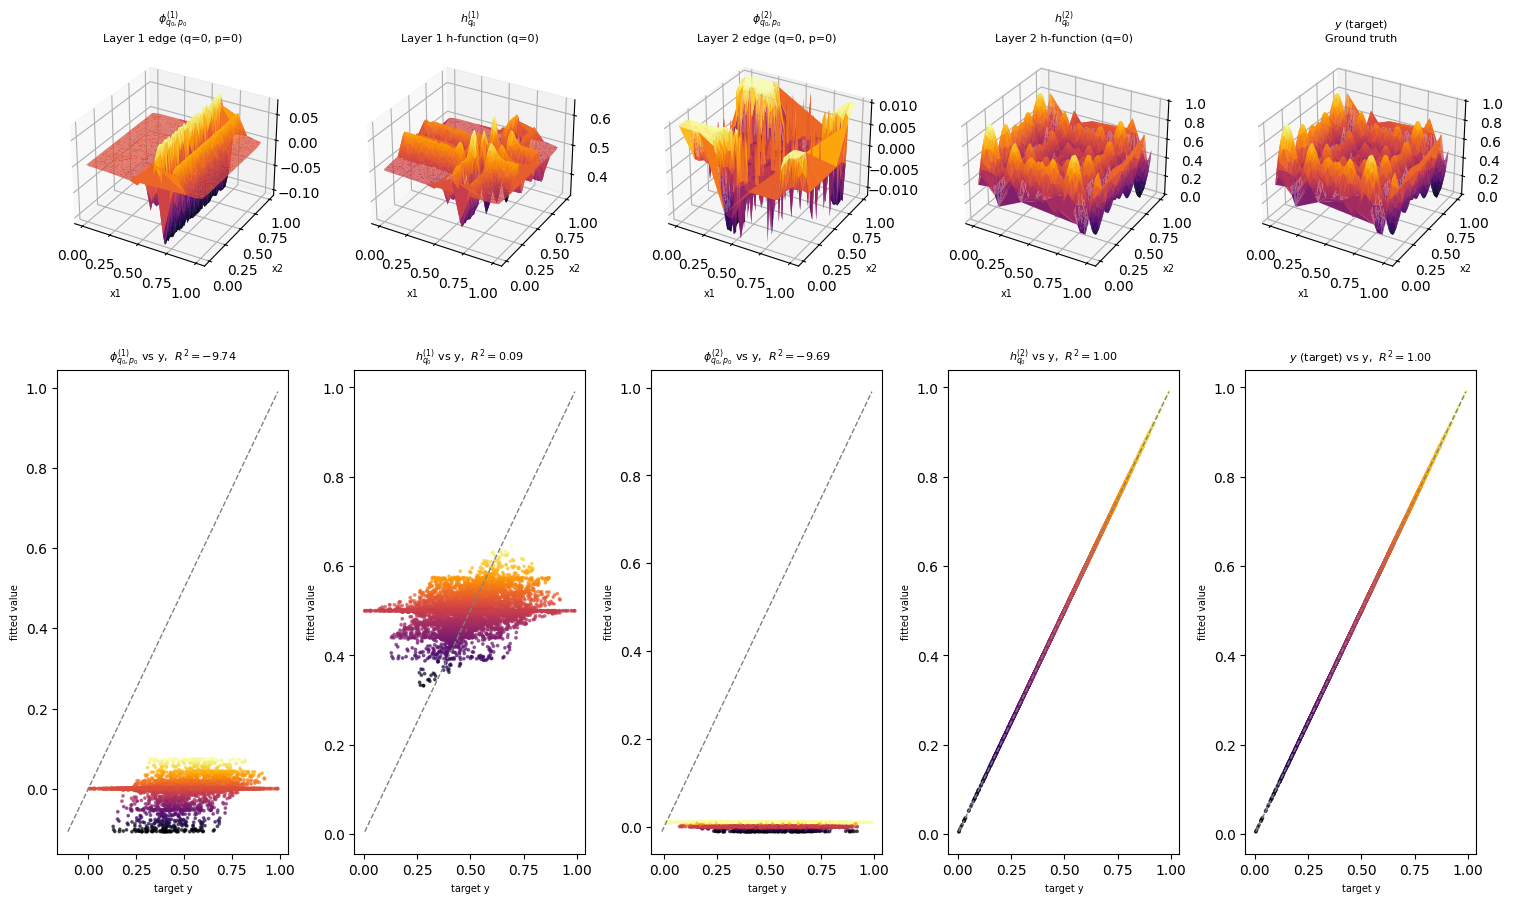

In [25]:
plot_hkan_stages_dynamic(tf1_x_train, tf1_y_train, sgkan_stages, block_idx=(0, 0), seed=0)


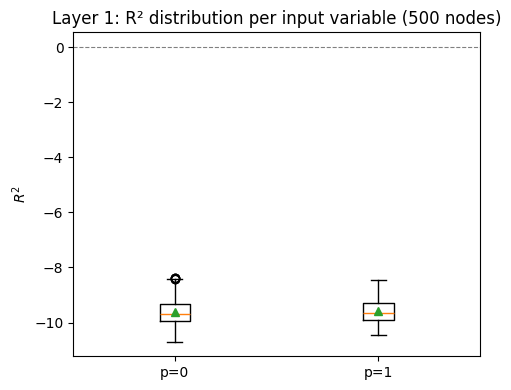

In [19]:
plot_first_layer_blf_r2_summary(sgkan_stages, tf1_y_train)


## Adim 14 — Adil R2 karsilastirmasi (bias dahil)

HKAN'in basis fonksiyonlari (Sigmoid/Tanh) global destekli oldugu icin tek
basina y'nin olcegine yakin durabiliyor, bu yuzden R2'leri sifira yakin
cikiyor. Bizim kenarlarimiz (RBF) yerel destekli oldugu icin sifir etrafinda
kucuk bir duzeltme uretiyor -- bias'i (o noronun ortak sabiti) eklemeden R2
hesaplarsak, cok daha negatif (yaniltici) bir sonuc cikiyor.

Bu bolum, `phi[q,p,:] + bias[q]` uzerinden R2 hesaplayan bir varyant ekliyor
-- HKAN ile DAHA ADIL (ama hala mukemmel esit olmayan -- asagida not var)
bir karsilastirma icin.

In [20]:
def build_sgkan_stack_with_neurons(X_train, y_train, layer_configs):
    """build_sgkan_stack ile ayni, ama her katmanin neurons listesini de saklar
    (bias'a erismek icin -- adil R2 karsilastirmasi bunu gerektiriyor)."""
    X_current = X_train
    stages = []
    neurons_all = []
    for i, cfg in enumerate(layer_configs, start=1):
        phi, h, neurons = sgkan_layer_step(X_current, y_train, **cfg)
        stages.append((i, phi, h))
        neurons_all.append(neurons)
        X_current = h
    yhat = stages[-1][2].ravel()
    return stages, yhat, neurons_all


def plot_first_layer_blf_r2_summary_biased(stages, neurons_all, y_train):
    """
    plot_first_layer_blf_r2_summary ile AYNI grafik, ama R2'yi
    phi[q,p,:] + bias[q] uzerinden hesaplar -- boylece SGKAN'in
    "bias + yerel duzeltme" mimarisi, HKAN'in "her BlF kendi basina
    kaba bir tahmin" mimarisiyle DAHA ADIL karsilastirilabilir.
    """
    layer_idx, phi, h = stages[0]
    neurons = neurons_all[0]
    n_vars_out, n_vars_in, _ = phi.shape

    data, labels = [], []
    for p in range(n_vars_in):
        r2_vals = [
            r2_score(y_train, phi[q, p, :] + neurons[q]["bias"])
            for q in range(n_vars_out)
        ]
        data.append(r2_vals)
        labels.append(f"p={p}")

    _, ax = plt.subplots(figsize=(1.5 * n_vars_in + 2, 4))
    ax.boxplot(data, tick_labels=labels, showmeans=True)
    ax.set_title(f"Layer {layer_idx}: R² (bias dahil) dagilimi, giris degiskenine gore ({n_vars_out} noron)")
    ax.set_ylabel(r"$R^2$ (bias + kenar)")
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    plt.tight_layout()
    plt.show()


### Calistirma — bias-dahil karsilastirma

In [21]:
sgkan_stages_b, sgkan_yhat_b, neurons_all_b = build_sgkan_stack_with_neurons(
    tf1_x_train, tf1_y_train, sgkan_layer_configs)

layer_idx, phi, h = sgkan_stages_b[0]
neurons = neurons_all_b[0]
n_vars_out, n_vars_in, _ = phi.shape

print("Bias-dahil R2 ozeti:")
for p in range(n_vars_in):
    r2_vals = [r2_score(tf1_y_train, phi[q, p, :] + neurons[q]["bias"]) for q in range(n_vars_out)]
    print(f"p={p}: R2 ortalama(bias dahil)={np.mean(r2_vals):.4f}, "
          f"max={np.max(r2_vals):.4f}, min={np.min(r2_vals):.4f}")


Bias-dahil R2 ozeti:
p=0: R2 ortalama(bias dahil)=0.1081, max=0.2785, min=-0.0276
p=1: R2 ortalama(bias dahil)=0.1156, max=0.2594, min=-0.0276


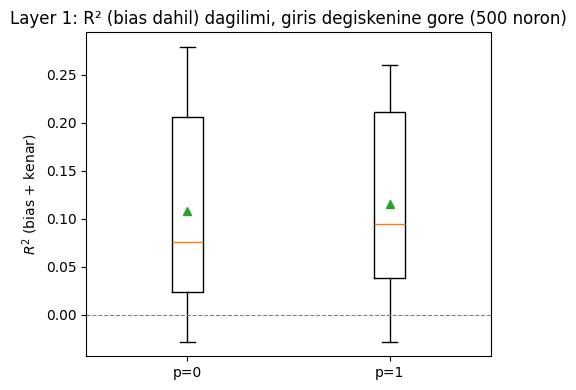

In [22]:
plot_first_layer_blf_r2_summary_biased(sgkan_stages_b, neurons_all_b, tf1_y_train)


**Not:** Bu duzeltme yaklasik bir iyilestirme -- HKAN'in her BlF'i kendi
TAM OLS fit'ine (kendi intercept'i dahil) sahipken, SGKAN'in kenarlari
NORONUN PAYLASILAN bias'ini kullaniyor (D boyutun ortak sabiti, tek bir
boyuta ozel degil). Yani bu karsilastirma gostergesel/yaklasiktir, birebir
esit-kosul karsilastirmasi degildir -- tez metninde bu sinirlamayi acikca
belirtmeniz onerilir.